TASK 1: IRIS DATASET ANALYSIS

1. Dataset Shape: (150, 5)

2. Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

3. First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

4. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), objec

/tmp/ipykernel_13066/4041947519.py:46: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.drop('species', axis=1).hist(ax=plt.gca(), bins=15, alpha=0.7)


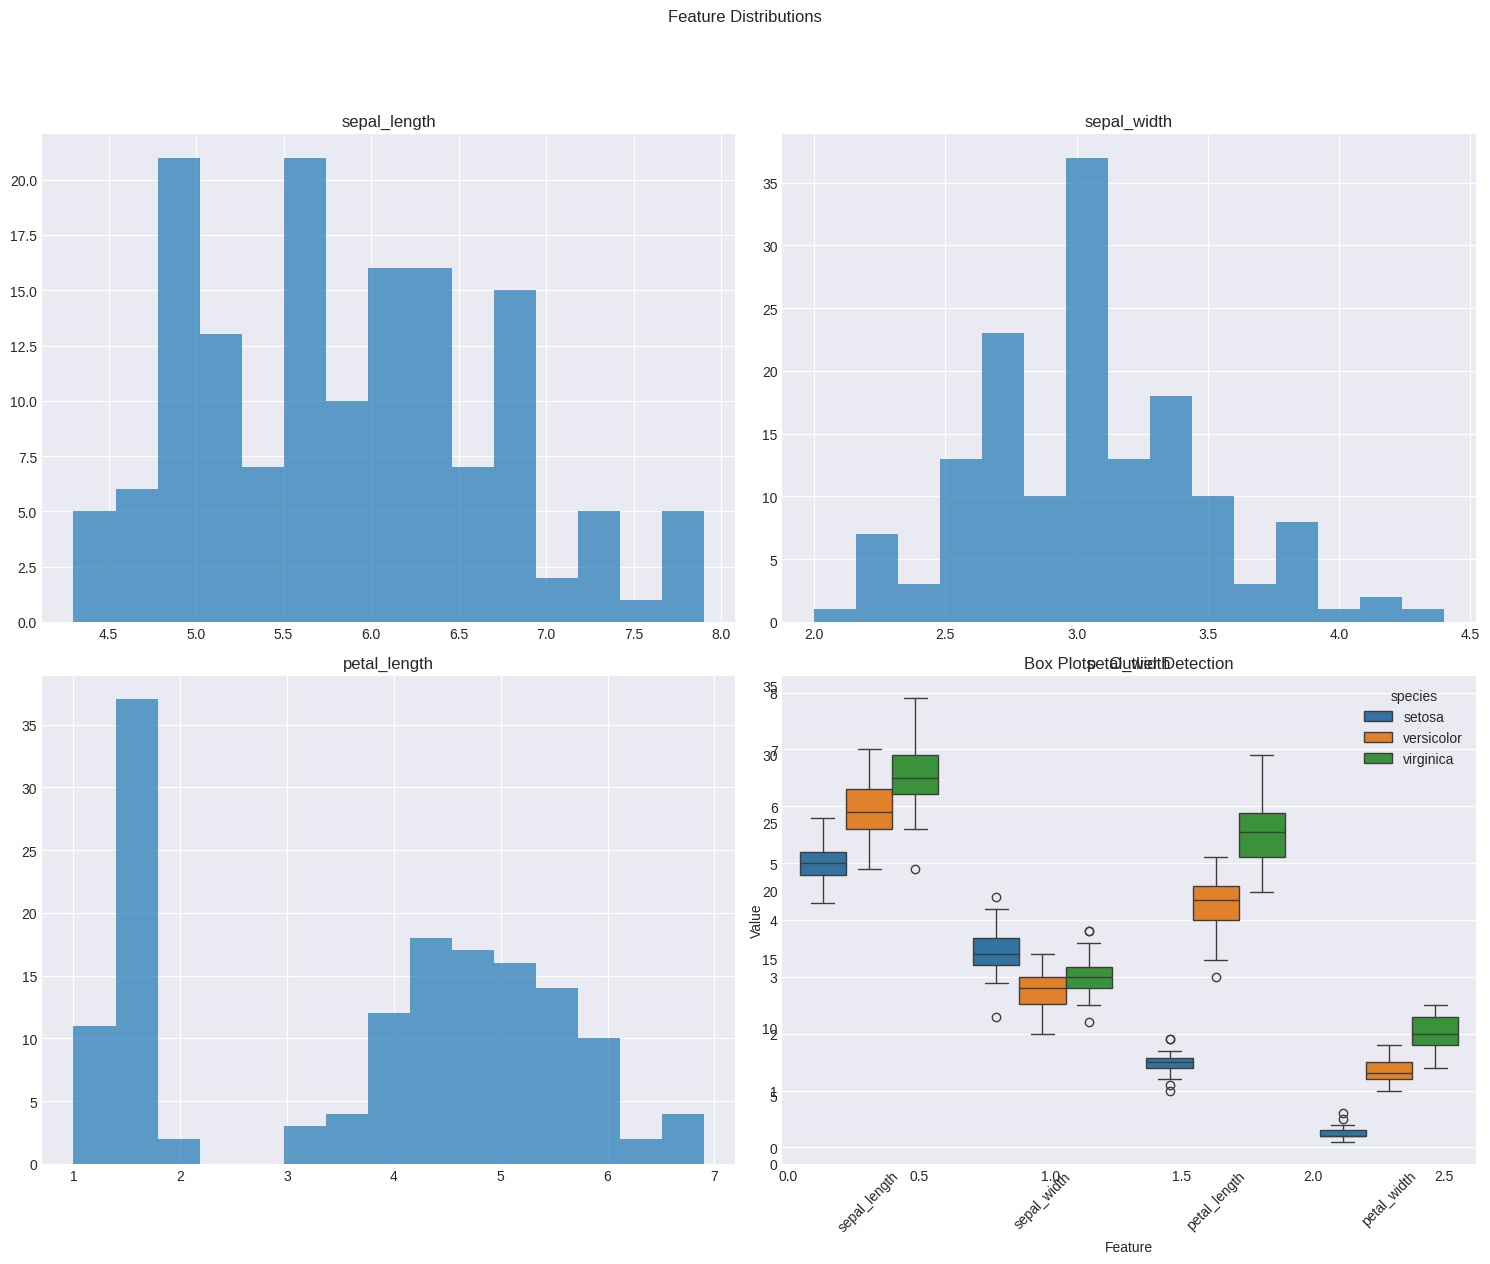

<Figure size 1000x800 with 0 Axes>

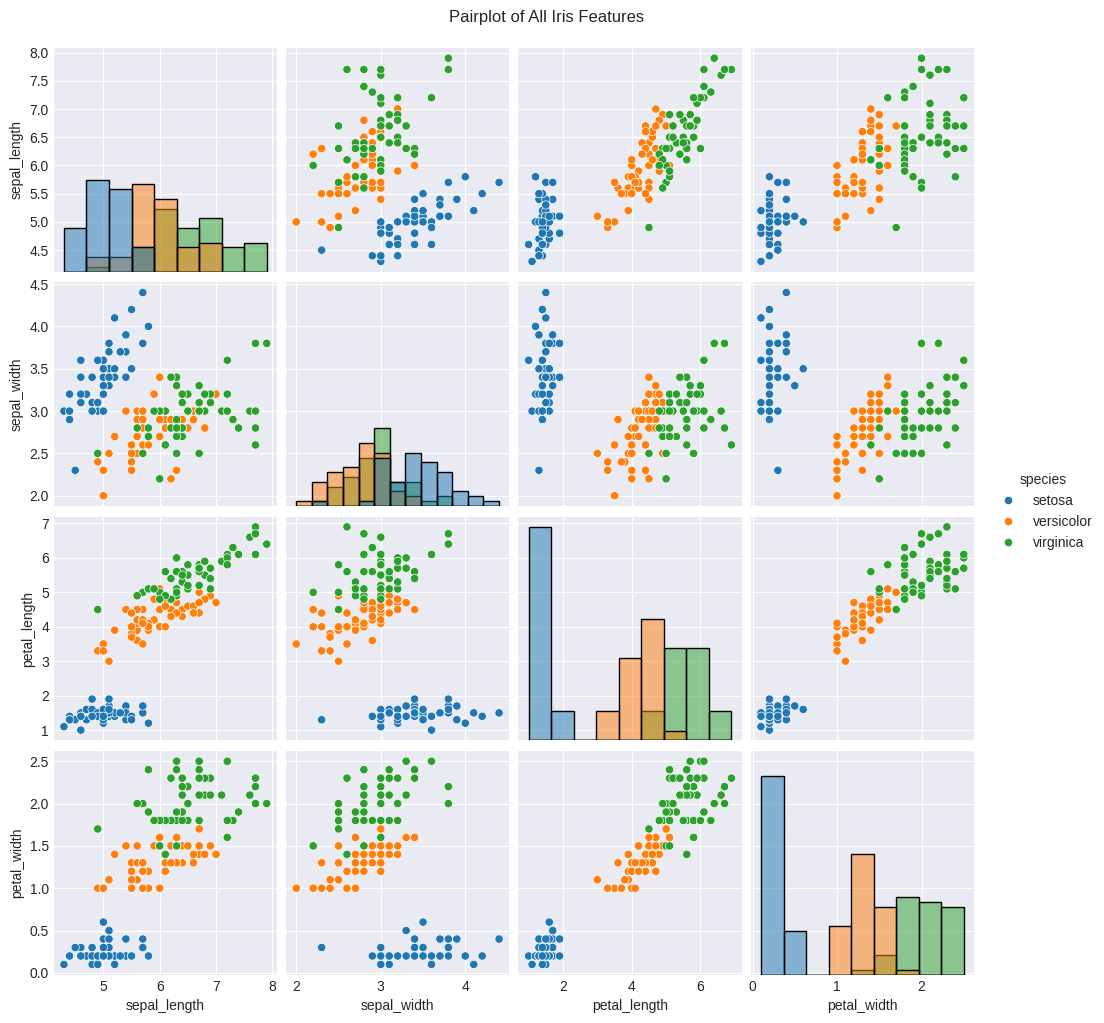

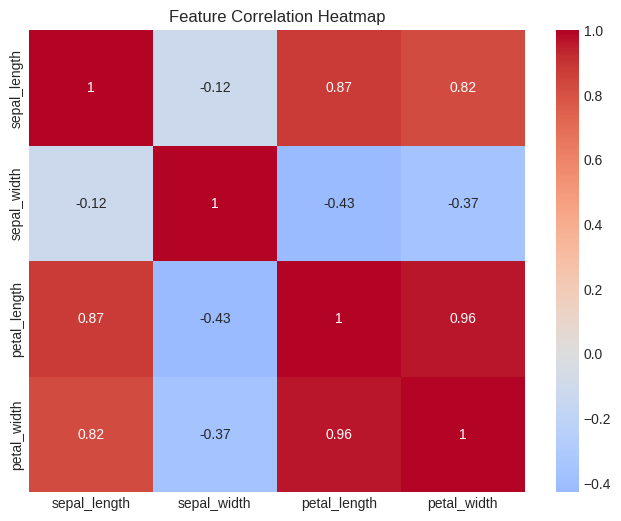


KEY INSIGHTS:
1. Setosa is clearly separable from other species
2. Petal features have high correlation (0.96)
3. No outliers detected in any feature
4. All features follow roughly normal distributions
5. Virginica and Versicolor have some overlap

✅ Task 1 Completed Successfully!


In [1]:
# Task 1: Iris Dataset Exploration and Visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = sns.load_dataset('iris')

print("="*50)
print("TASK 1: IRIS DATASET ANALYSIS")
print("="*50)

# 1. Basic inspection
print("\n1. Dataset Shape:", df.shape)
print("\n2. Column Names:", list(df.columns))
print("\n3. First 5 rows:")
print(df.head())

# 2. Summary statistics
print("\n4. Dataset Info:")
print(df.info())

print("\n5. Statistical Summary:")
print(df.describe())

print("\n6. Missing values:", df.isnull().sum().sum())

# 3. Visualizations
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(15, 12))

# 3a: Scatter plot matrix
fig.add_subplot(2, 2, 1)
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species')
plt.title('Sepal Length vs Sepal Width by Species')

fig.add_subplot(2, 2, 2)
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')
plt.title('Petal Length vs Petal Width by Species')

# 3b: Histograms
fig.add_subplot(2, 2, 3)
df.drop('species', axis=1).hist(ax=plt.gca(), bins=15, alpha=0.7)
plt.suptitle('Feature Distributions', y=1.05)
plt.tight_layout()

# 3c: Box plots (outlier detection)
fig.add_subplot(2, 2, 4)
df_melted = df.melt(id_vars='species', var_name='Feature', value_name='Value')
sns.boxplot(data=df_melted, x='Feature', y='Value', hue='species')
plt.title('Box Plots - Outlier Detection')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Pairplot (most informative)
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle('Pairplot of All Iris Features', y=1.02)
plt.show()

# 5. Correlation heatmap
plt.figure(figsize=(8, 6))
correlation = df.drop('species', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

print("\n" + "="*50)
print("KEY INSIGHTS:")
print("="*50)
print("1. Setosa is clearly separable from other species")
print("2. Petal features have high correlation (0.96)")
print("3. No outliers detected in any feature")
print("4. All features follow roughly normal distributions")
print("5. Virginica and Versicolor have some overlap")
print("\n✅ Task 1 Completed Successfully!")

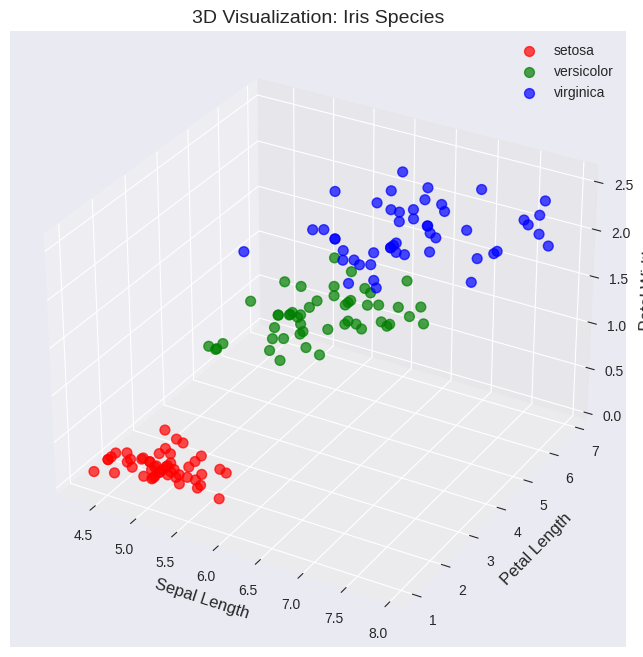

In [2]:
# Advanced Visualization 1: 3D Plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}

for species, color in colors.items():
    subset = df[df['species'] == species]
    ax.scatter(subset['sepal_length'],
               subset['petal_length'],
               subset['petal_width'],
               c=color, label=species, s=50, alpha=0.7)

ax.set_xlabel('Sepal Length', fontsize=12)
ax.set_ylabel('Petal Length', fontsize=12)
ax.set_zlabel('Petal Width', fontsize=12)
ax.set_title('3D Visualization: Iris Species', fontsize=14)
ax.legend()
plt.show()


/tmp/ipykernel_13066/1243425119.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
/tmp/ipykernel_13066/1243425119.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
/tmp/ipykernel_13066/1243425119.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
/tmp/ipykernel_13066/1243425119.py:8: FutureWarning: 

Passing `palette` without a

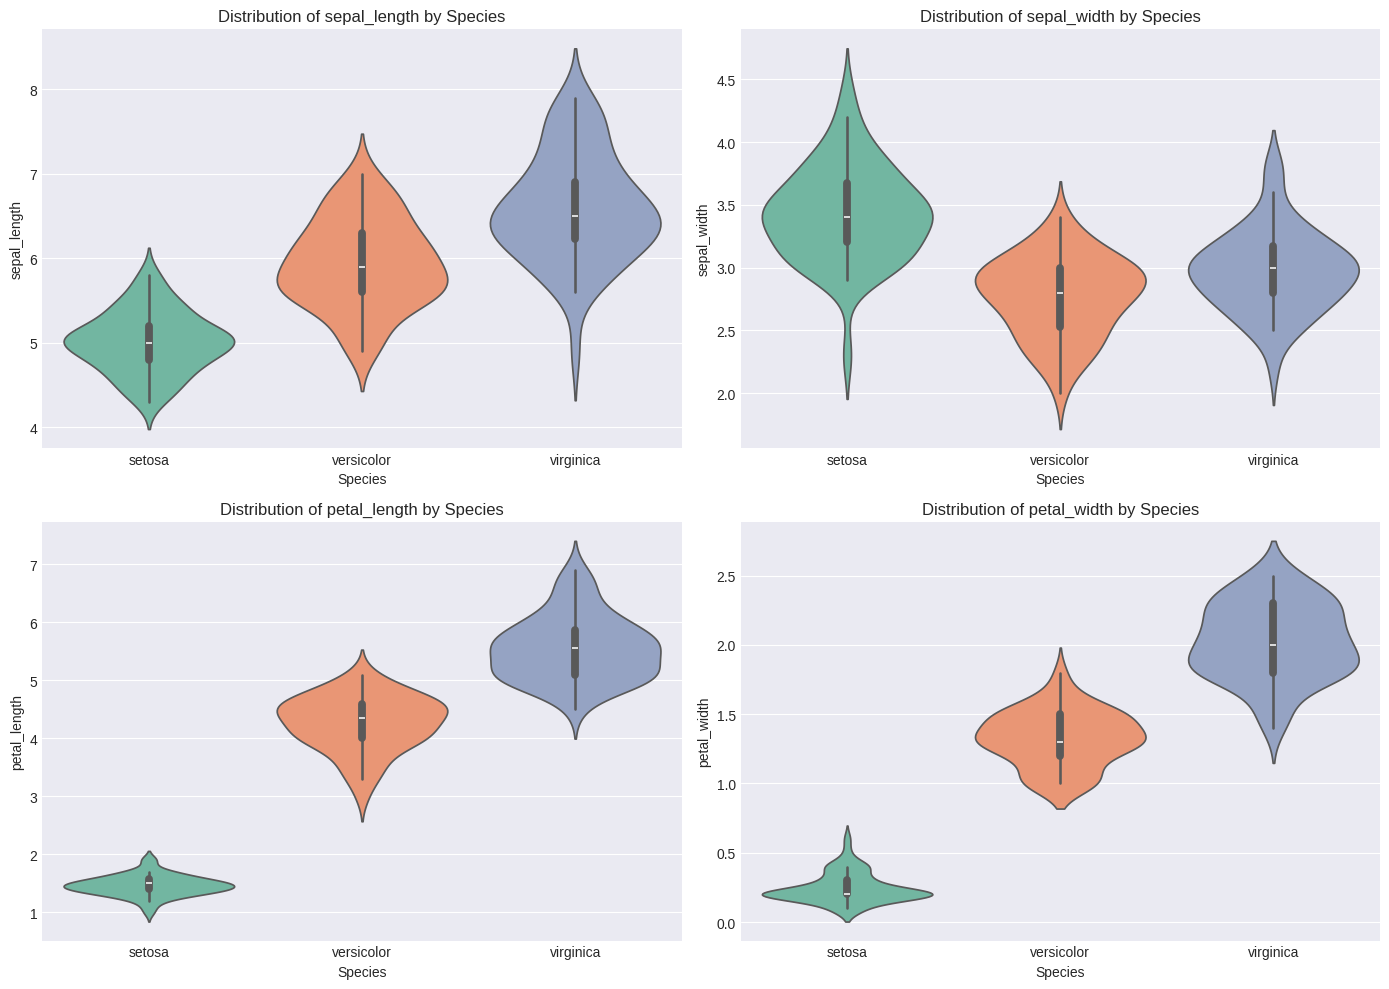

In [3]:
# Advanced Visualization 2: Violin Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.violinplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'Distribution of {feature} by Species', fontsize=12)
    axes[row, col].set_xlabel('Species')
    axes[row, col].set_ylabel(feature)

plt.tight_layout()
plt.show()

/tmp/ipykernel_13066/2234604718.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')


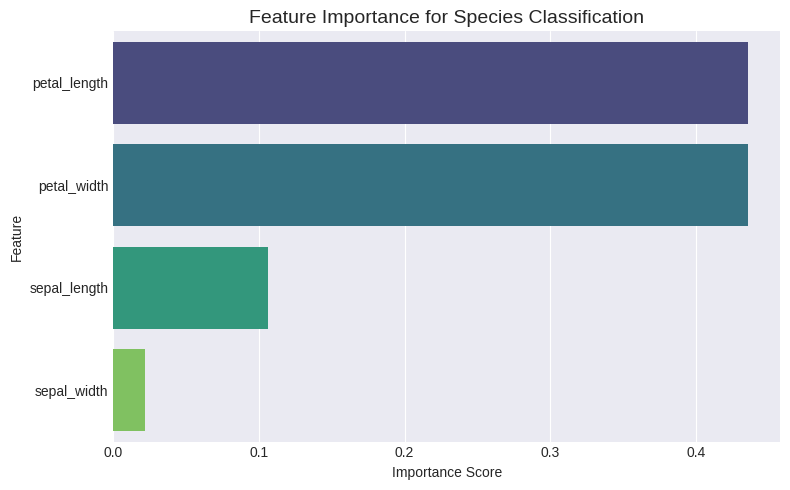


Feature Importance Ranking:
  petal_length: 0.436
  petal_width: 0.436
  sepal_length: 0.106
  sepal_width: 0.022


In [6]:
# Advanced Analysis: Feature Importance
from sklearn.ensemble import RandomForestClassifier

# Prepare data
X = df.drop('species', axis=1)
y = df['species']

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Get feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Species Classification', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for i, row in importance.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.3f}")

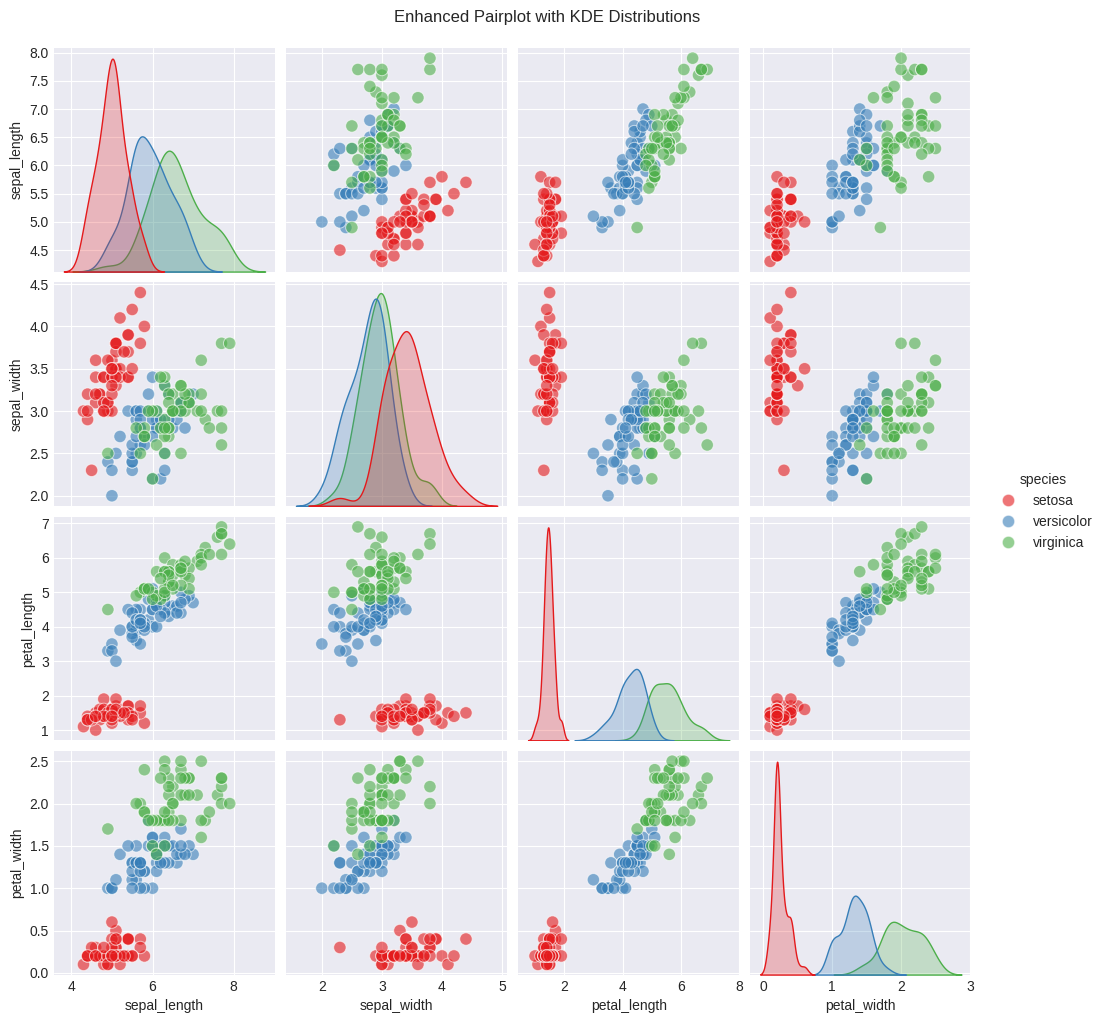

In [7]:
# Advanced Visualization 4: Enhanced Pairplot
g = sns.pairplot(df, hue='species', diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 80},
                 diag_kws={'fill': True},
                 palette='Set1')
g.fig.suptitle('Enhanced Pairplot with KDE Distributions', y=1.02)
plt.show()